(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
descr

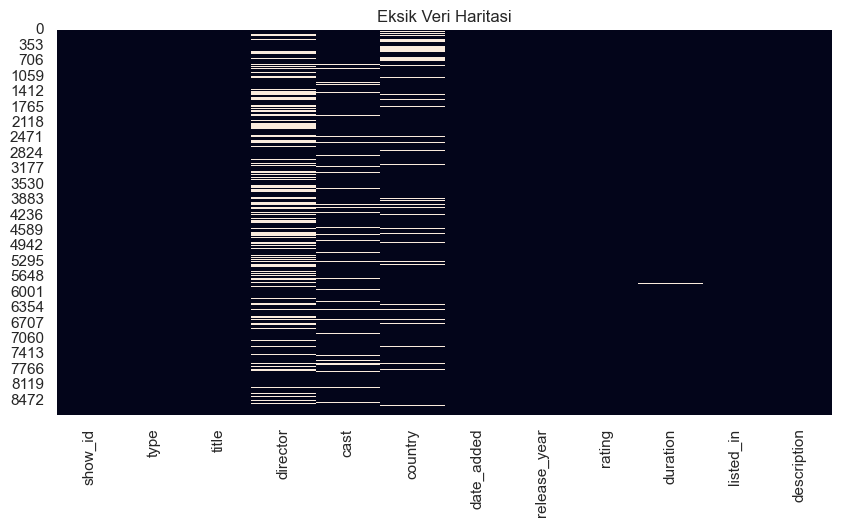

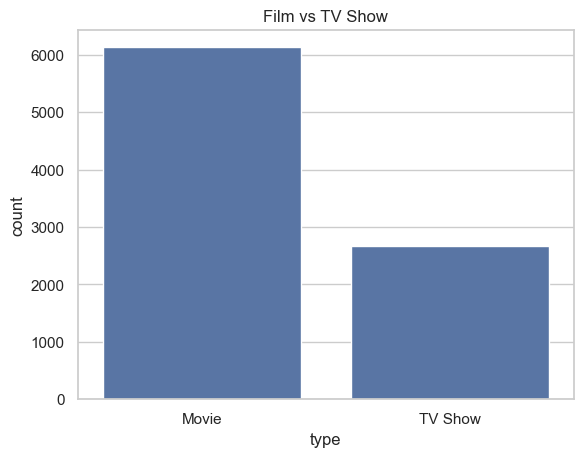

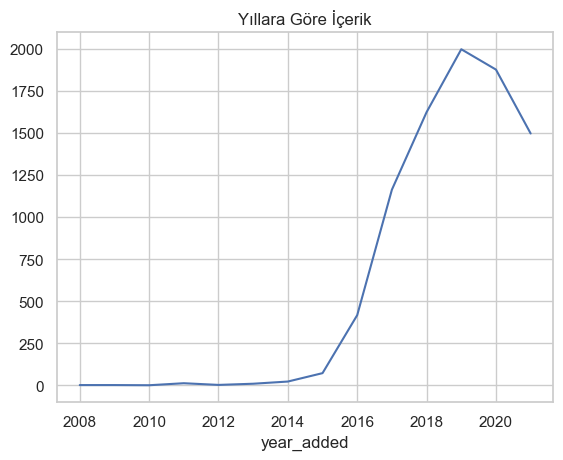

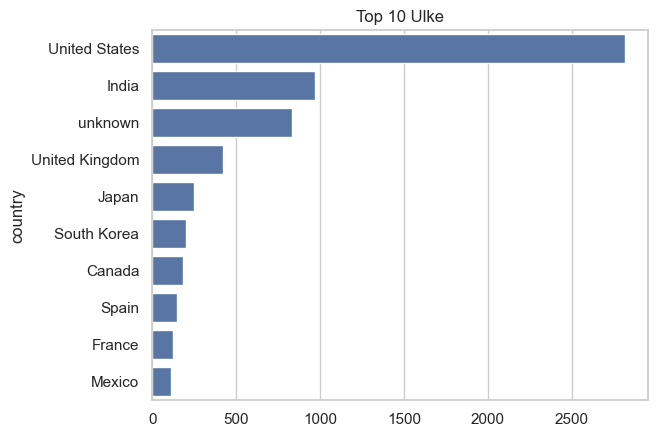

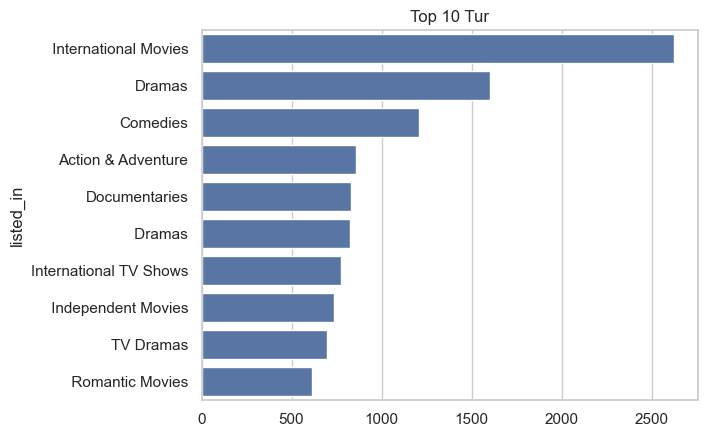

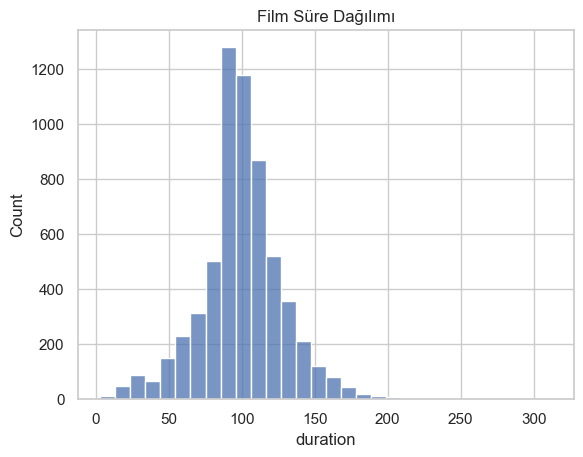

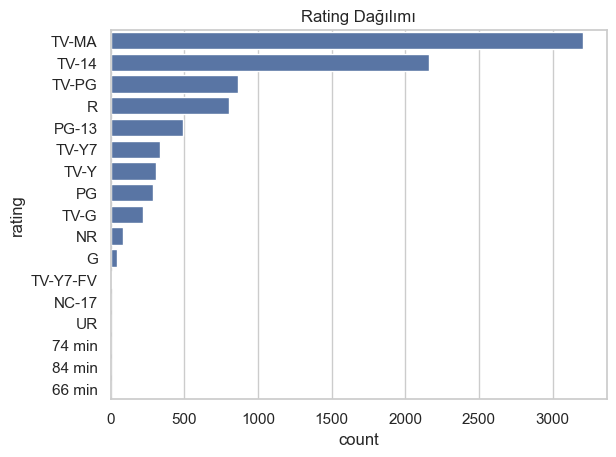

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os

os.makedirs("outputs/figures", exist_ok=True)

sns.set(style="whitegrid")

df = pd.read_csv("../data/netflix_titles.csv")

#genel bilgi
print(df.shape)
print(df.info())

#eksik veri
print(df.isnull().sum())

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Eksik Veri Haritasi")
plt.savefig("../outputs/figures/eksik_veri.png")
plt.show()

#type dagilimi
sns.countplot(data=df, x="type")
plt.title("Film vs TV Show")
plt.savefig("../outputs/figures/film_vs_tvshow.png")
plt.show()

#yillara gore icerik
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

df['year_added'].value_counts().sort_index().plot()
plt.title("Yıllara Göre İçerik")
plt.savefig("../outputs/figures/yil_icerik.png")
plt.show()

#ulkeler
df['country'] = df['country'].fillna("unknown")
top_countries = df['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Ulke")
plt.savefig("../outputs/figures/top10_ulke.png")
plt.show()

#tur analizi
df['listed_in'] = df['listed_in'].str.split(',')
genres = df.explode('listed_in')

top_genres = genres['listed_in'].value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Tur")
plt.savefig("../outputs/figures/top10_tur.png")
plt.show()

#film sureleri
movies = df[df['type']=="Movie"].copy()
movies['duration'] = movies['duration'].str.replace(" min","")
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

sns.histplot(movies['duration'], bins=30)
plt.title("Film Süre Dağılımı")
plt.savefig("../outputs/figures/film_sure.png")
plt.show()

#rating dagilimi
sns.countplot(data=df, y="rating", order=df['rating'].value_counts().index)
plt.title("Rating Dağılımı")
plt.savefig("../outputs/figures/film_rating.png")
plt.show()
